# Weekly Project - Week 3: Implementing Stereo Block Matching

We build our own block matching from scratch. We do not use `cv2.matchTemplate`, `cv2.StereoBM`, or any other ready made matching function. We only use Sum of Absolute Differences (SAD) and sliding windows, built with NumPy.

- Step 1: SAD function on `nose_left.png` and `nose_right.png`
- Step 2: best match among `nose1.png`, `nose2.png`, `nose3.png`
- Step 3: sliding window search across `nose_span.png`
- Challenge: full disparity map on `tsukuba_left.png` and `tsukuba_right.png`

In [22]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

## Intermediate Step 1 - Sum of Absolute Differences

This is the basic building block of block matching. We take two patches of the same size and add up the absolute difference between their pixel values. A low SAD score means the patches look similar.

In [23]:
def sad(patch_a, patch_b):
    """Sum of absolute differences between two same size patches."""
    a = patch_a.astype(np.int32)
    b = patch_b.astype(np.int32)
    return np.sum(np.abs(a - b))

nose_left shape: (7, 7)  nose_right shape: (7, 7)


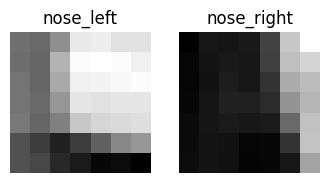

SAD(nose_left, nose_right) = 7657


In [24]:
nose_left  = cv2.imread('nose_left.png', cv2.IMREAD_GRAYSCALE)
nose_right = cv2.imread('nose_right.png', cv2.IMREAD_GRAYSCALE)
print('nose_left shape:', nose_left.shape, ' nose_right shape:', nose_right.shape)

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].imshow(nose_left,  cmap='gray'); axes[0].set_title('nose_left'); axes[0].axis('off')
axes[1].imshow(nose_right, cmap='gray'); axes[1].set_title('nose_right'); axes[1].axis('off')
plt.show()

print('SAD(nose_left, nose_right) =', sad(nose_left, nose_right))

The SAD score is quite high here. `nose_left.png` and `nose_right.png` are cropped from the same pixel position in the left and right image. But the two cameras see the nose from a different angle, so in the right image the nose has moved to a different column. Comparing the same position in both images is not correct for stereo matching. Steps 2 and 3 fix this by searching for the best match, instead of just assuming it is at the same position.

## Intermediate Step 2 - Best match among 3 candidates

`nose1.png`, `nose2.png`, and `nose3.png` are three candidate patches. Each one is cropped from a different position in the same row of the right image. We use our `sad` function to check which candidate matches the `nose_left` template best.

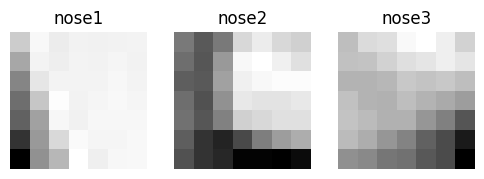

In [25]:
candidates = {i: cv2.imread(f'nose{i}.png', cv2.IMREAD_GRAYSCALE) for i in [1, 2, 3]}

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
for i, patch in candidates.items():
    axes[i-1].imshow(patch, cmap='gray')
    axes[i-1].set_title(f'nose{i}')
    axes[i-1].axis('off')
plt.show()

In [26]:
scores = {i: sad(nose_left, patch) for i, patch in candidates.items()}
for i, s in scores.items():
    print(f'SAD(nose_left, nose{i}) = {s}')

best = min(scores, key=scores.get)
print(f'\nBest match: nose{best}  (lowest SAD = {scores[best]})')
print(f'Compare to the naive same position SAD from Step 1: {sad(nose_left, nose_right)}, searching clearly wins.')

SAD(nose_left, nose1) = 1361
SAD(nose_left, nose2) = 119
SAD(nose_left, nose3) = 1490

Best match: nose2  (lowest SAD = 119)
Compare to the naive same position SAD from Step 1: 7657, searching clearly wins.


## Intermediate Step 3 - Sliding window search across a row

The stereo pair is rectified. This means the matching pixel is on the same row in both images. `nose_span.png` contains that full row, with height 7, the same height as our template. Instead of checking only 3 candidates, we now slide the template across every possible x position, and keep the one with the lowest SAD score.

In [27]:
def search_row(template, row_strip, block_w):
    """Slide template across row_strip and return the best match.

    Returns best_x, best_score, and all_scores.
    best_x is the left edge of the best matching window.
    """
    scores = []
    for x in range(row_strip.shape[1] - block_w + 1):
        window = row_strip[:, x:x+block_w]
        scores.append(sad(template, window))
    scores = np.array(scores)
    best_x = int(np.argmin(scores))
    return best_x, scores[best_x], scores

nose_span shape: (7, 384)
Best match at x=132, SAD=119
(Matches the nose2 score of 119 from Step 2, same physical location)


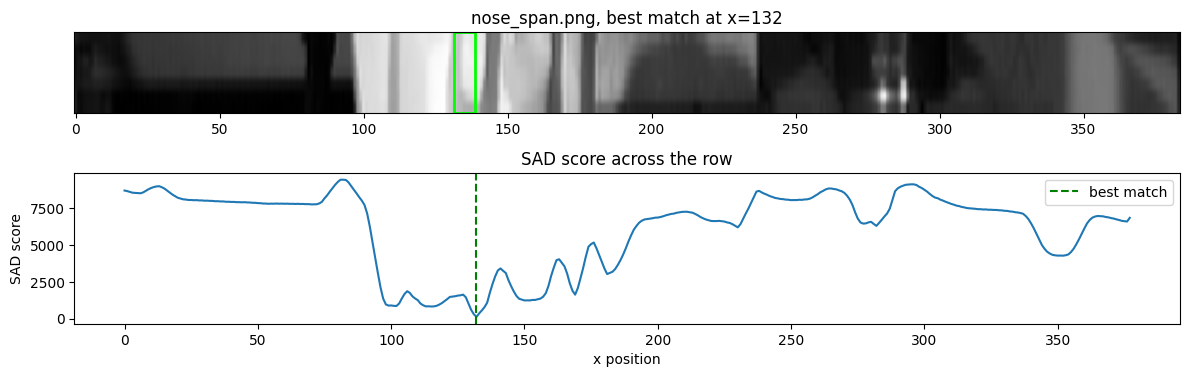

In [28]:
nose_span = cv2.imread('nose_span.png', cv2.IMREAD_GRAYSCALE)
print('nose_span shape:', nose_span.shape)

block_w = nose_left.shape[1]
best_x, best_score, all_scores = search_row(nose_left, nose_span, block_w)
print(f'Best match at x={best_x}, SAD={best_score}')
print(f'(Matches the nose2 score of {scores[2]} from Step 2, same physical location)')

fig, axes = plt.subplots(2, 1, figsize=(12, 4))
axes[0].imshow(nose_span, cmap='gray', aspect=4)
axes[0].axvspan(best_x - 0.5, best_x + block_w - 0.5, facecolor='none', edgecolor='lime', linewidth=2)
axes[0].set_title(f'nose_span.png, best match at x={best_x}')
axes[0].set_yticks([])
axes[1].plot(all_scores)
axes[1].axvline(best_x, color='green', linestyle='--', label='best match')
axes[1].set_xlabel('x position'); axes[1].set_ylabel('SAD score')
axes[1].set_title('SAD score across the row')
axes[1].legend()
plt.tight_layout()
plt.show()

The sliding window search lands exactly on the true nose location, with the same SAD score as `nose2`. We found this only by brute force scanning with our own SAD function. No OpenCV matching function was used.

## Challenge - Full disparity map on the Tsukuba stereo pair

We now scale up Step 3. For every 7x7 template position in `tsukuba_left.png`, we search the same row in `tsukuba_right.png`, and store the disparity of the best match. Doing this for every pixel builds a full disparity map.

In [ ]:
"Early full template matching row using nested for loops to search for a template along "
def SAD(img_left, img_right): 
       
                
    img_new=np.abs(img_left.astype(np.int32)-img_right.astype(np.int32))
    
    return np.sum(img_new) 

def SSD_values_along_span(span, template, kernel_size):
    span=span.copy()
    sad=[]

    for i in range(span.shape[0]):
        for j in range(span.shape[1]):
            if (i == kernel_size-1 and j + kernel_size <= span.shape[1]): #once it is at a corner at 7 height
                img_compare=np.zeros(template.shape, dtype=np.int32)

                for k in range(kernel_size):
                    for l in range(kernel_size):
                        img_compare[k,l]=span[k,j+l]

                sad.append(SAD(img_compare,template))
            else:
                continue

    return sad

def full_template_matching(img_left, img_right):
    disparity_map=np.zeros(img_left.shape, dtype=np.int16) # contains the best disparity values for each pixel
    min_val=np.inf  

    for i in range(img_right.shape[0]): # select row 
        if i>2 and i<img_right.shape[0]-3: # centre based approach
            span=img_right[i-3:i+4,:] # create span using the row 

            for j in range(img_left.shape[1]):
                if j>2 and j<img_left.shape[1] - 3:
                    template = img_left[i-3:i+4, j-3:j+4] # template slice

                    vals = SSD_values_along_span(template = template, kernel_size = 7, span = span)

                    best_x = np.argmin(vals)

                    matched_x = best_x + 3

                    disparity = j - matched_x # j - value with lowest sad

                    best_values[i,j]= disparity

    return disparity_map

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

def compute_disparity_map(left_gray, right_gray, block_size=7, max_disparity=64):
    """
    For each block in left_gray, search the same row in right_gray for the
    best SAD match. This uses the rectified stereo assumption, the match
    is always on the same row.

    The search only checks x' in [x - max_disparity, x], since a matching
    point in the right image only ever shifts left compared to the left
    image.

    max_disparity limits how far we search. Without it, we would compare
    every template against every position in the row, which is slow and
    not needed here, since this scene's true disparities stay small.

    Computationally less expensive as the nested for loops are omitted.
    """
    half = block_size // 2
    h, w = left_gray.shape
    disparity_map = np.zeros((h, w), dtype=np.float32)

    for y in range(half, h - half):
        # All possible block_size x block_size windows along this row of the
        # right image, computed once per row.
        right_row = right_gray[y-half:y+half+1, :].astype(np.int32)
        right_windows = sliding_window_view(right_row, (block_size, block_size))[0]
        # right_windows[i] = the window whose left edge is at column i

        for x in range(half, w - half):
            template = left_gray[y-half:y+half+1, x-half:x+half+1].astype(np.int32)

            search_lo = max(0, (x - half) - max_disparity)
            search_hi = (x - half) + 1  # candidates with left edge <= template's left edge
            candidates = right_windows[search_lo:search_hi]

            diffs = np.abs(candidates - template)
            scores = diffs.sum(axis=(1, 2))          # SAD per candidate
            best_local = np.argmin(scores)
            best_left_edge = search_lo + best_local

            disparity_map[y, x] = (x - half) - best_left_edge

    return disparity_map

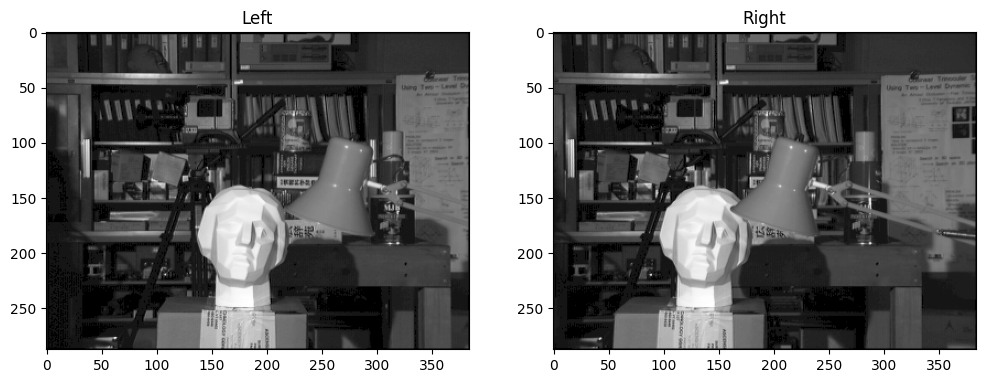

In [30]:
gray_left  = cv2.imread('tsukuba_left.png',  cv2.IMREAD_GRAYSCALE)
gray_right = cv2.imread('tsukuba_right.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1), plt.imshow(gray_left,  cmap='gray'), plt.title('Left')
plt.subplot(1, 2, 2), plt.imshow(gray_right, cmap='gray'), plt.title('Right')
plt.show()

Computed in 1.5s


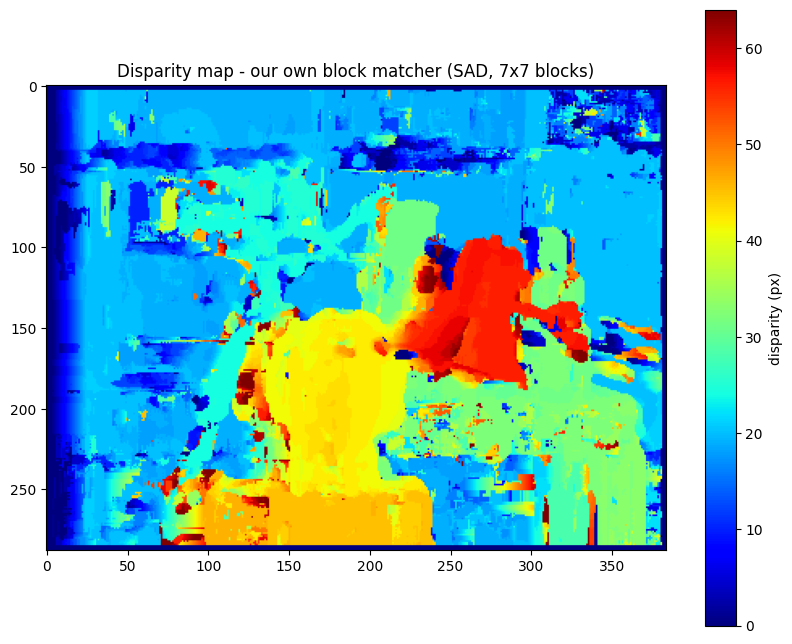

In [31]:
import time
t0 = time.time()
disparity_map = compute_disparity_map(gray_left, gray_right, block_size=7, max_disparity=64)
print(f'Computed in {time.time() - t0:.1f}s')

plt.figure(figsize=(10, 8))
plt.imshow(disparity_map, cmap='jet')
plt.colorbar(label='disparity (px)')
plt.title('Disparity map - our own block matcher (SAD, 7x7 blocks)')
plt.show()

Objects that are closer to the camera shift more between the left and right image, so they get a higher disparity value. In the classic Tsukuba scene, the lamp and the head sculpture are closest to the camera, so they should look brightest. The background bookshelf is farthest away, so it should look darkest.

This is the same idea as the `cv2.StereoBM` result from Exercise 2 from Week 3. Both use block matching with SAD. Here, we just implemented it by hand instead of using OpenCV's built in version.